# Phase 3: End-to-End Licence Plate Detection and Recognition

This notebook covers Phase 3 of the project. It connects the trained **YOLO26 detector** (Phase 1) and the best **CNN recognizer** (Phase 2) into one pipeline: *raw photo → detect plates → crop → read the 8 characters*. It then shows how that pipeline performs on the **held-out test split** (938 photos, 1,091 plates), which was never used for training or model selection.

The code lives in the package `src/platereader/`, mainly `pipeline.py` (the end-to-end class) and `e2e_eval.py` (the evaluation). The full evaluation is run by

```
python scripts/06_evaluate_end_to_end.py
```

and writes everything to `reports/end_to_end/`. This notebook loads those results and runs the pipeline live on a few test photos.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from platereader.pipeline import PlateRecognizer

REPORT = ROOT / "reports" / "phase3"
metrics = json.loads((REPORT / "end_to_end_metrics.json").read_text())
print("test images:", metrics["test_images"], "| backend:", metrics["backend"], "| device:", metrics["device"])

test images: 938 | backend: torch | device: mps


## 1. The end-to-end class

`PlateRecognizer` loads the model bundle in `models/` and exposes `detect()`, `recognize()` and `predict()`. It supports two interchangeable backends:
* **PyTorch:** Ultralytics YOLO + a TorchScript recognizer.
* **ONNX Runtime:** the same models, with the pre- and post-processing written out in numpy. The Android app runs exactly this, and a parity test confirms it reads the same 47/47 plates as Python.

In [2]:
reader = PlateRecognizer(ROOT / "models", backend="torch")
print("detector threshold:", reader.conf, "| image size:", reader.imgsz, "| crop padding:", reader.crop_padding)
print("letters:", " ".join(reader.letters))

detector threshold: 0.618 | image size: 960 | crop padding: 0.05
letters: الف آ ب پ ت ث ج د ز ژ س ش ص ط ع ق ل م ن و ه ی


/opt/anaconda3/envs/lpr/lib/python3.11/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


## 2. Results on the test split

**Detection** is scored with the standard mAP (Ultralytics, IoU 0.5 and 0.5–0.95).

**End-to-end**, a plate counts as correct only if it was detected (IoU ≥ 0.5) **and** all 8 characters were read exactly:
* **precision** = correct reads / predicted plates;
* **recall** = correct reads / real plates;
* **CER** = character error rate on the detected plates.

In [3]:
print("Detector on the test split:", {k: round(v, 4) for k, v in metrics["detector_test_map"].items()})
summary = pd.DataFrame(metrics["end_to_end"]).T
cols = ["threshold", "det_precision", "det_recall", "e2e_precision", "e2e_recall", "e2e_f1",
        "recognition_acc_on_detected", "cer_on_detected", "image_acc", "correct_reads", "gt_plates"]
display(summary[cols].round(4))
print("speed (ms per image):", {k: round(v, 1) for k, v in metrics["speed_ms_per_image"].items()})

Detector on the test split: {'precision': 0.9553, 'recall': 0.9762, 'mAP50': 0.9881, 'mAP50-95': 0.7843, 'fitness': 0.7843}


,threshold,det_precision,det_recall,e2e_precision,e2e_recall,e2e_f1,recognition_acc_on_detected,cer_on_detected,image_acc,correct_reads,gt_plates
phase1_threshold,0.618,0.9588,0.9588,0.8900,0.8900,0.8900,0.9283,0.0177,0.8561,971.0,1091.0
best_f1_threshold,0.650,0.9610,0.9478,0.9006,0.8882,0.8943,0.9371,0.0146,0.8571,969.0,1091.0


speed (ms per image): {'detect_ms': 44.8, 'recognize_ms': 12.1, 'total_ms': 66.3}


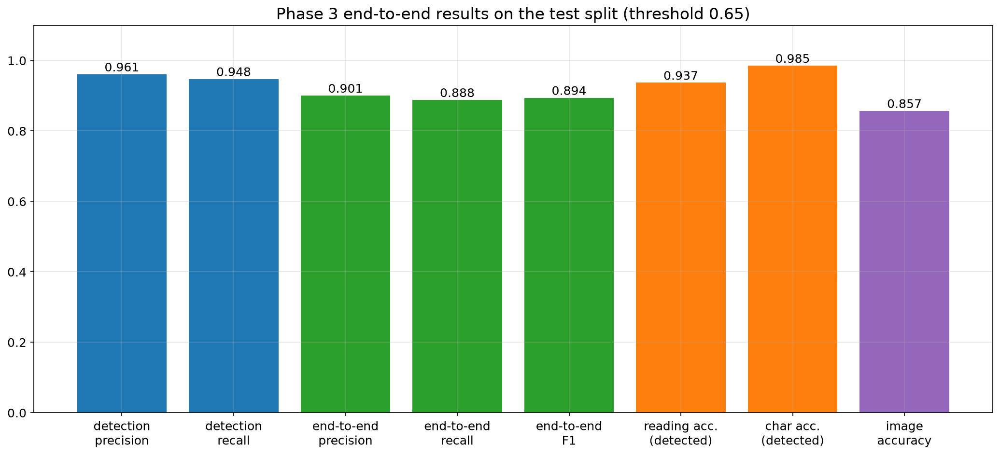

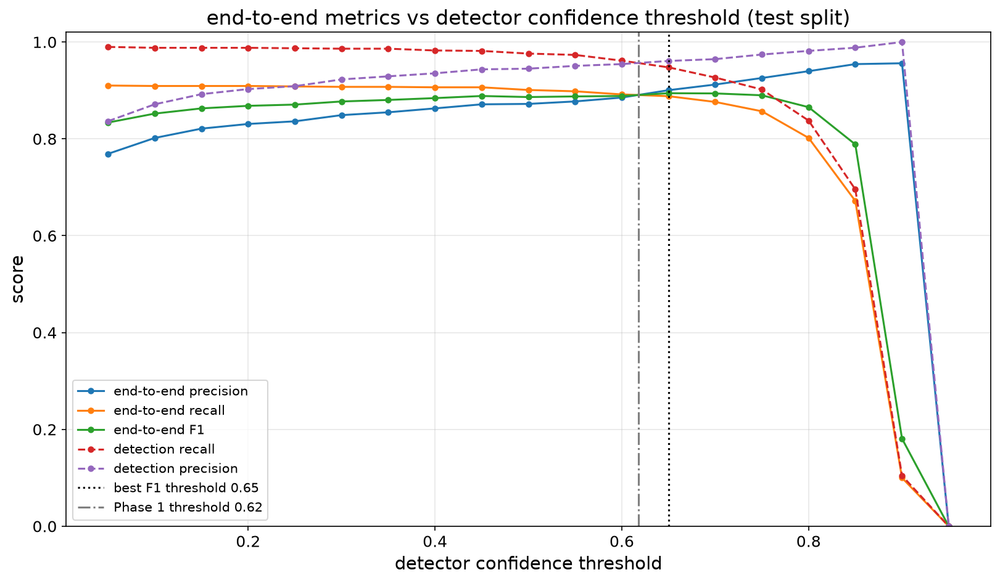

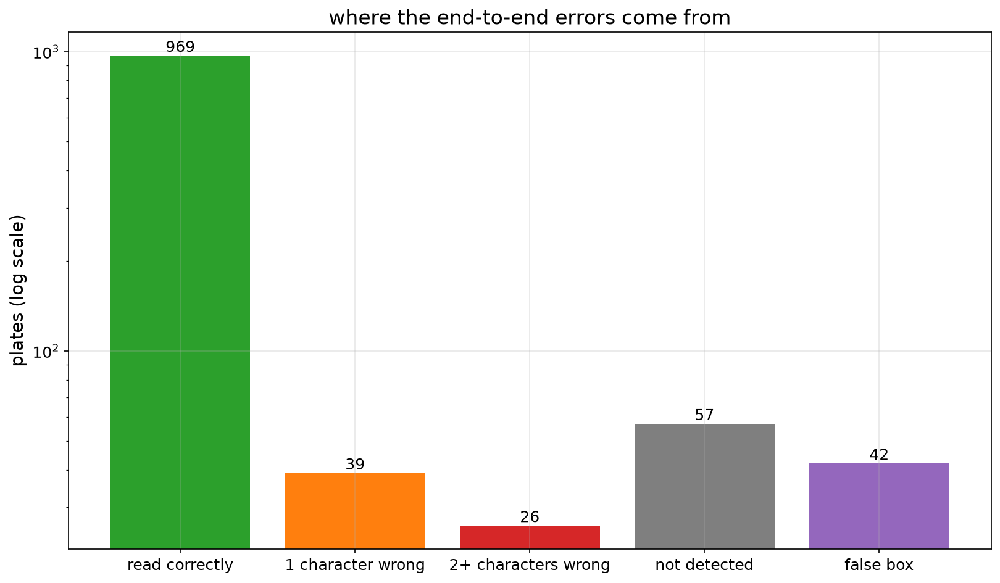

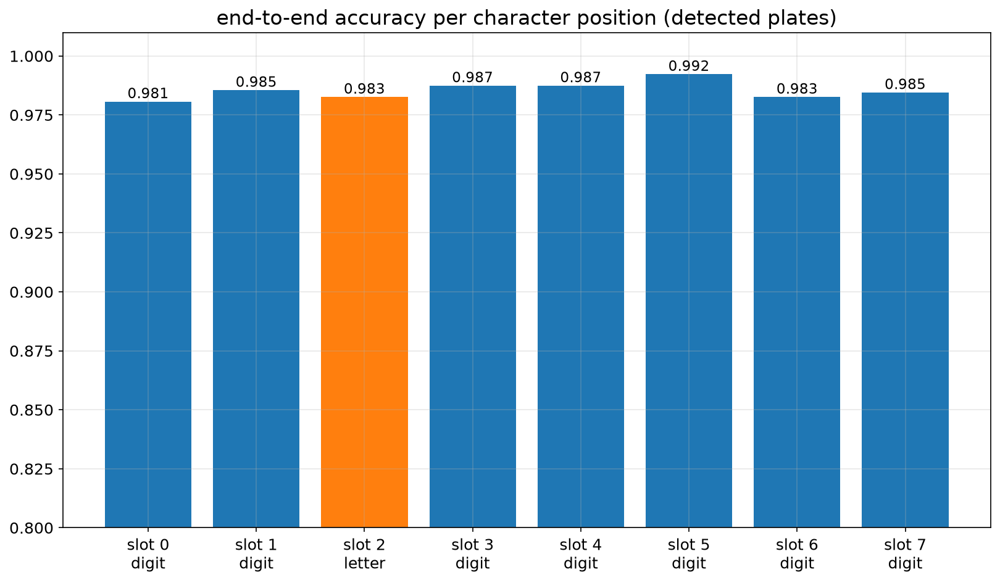

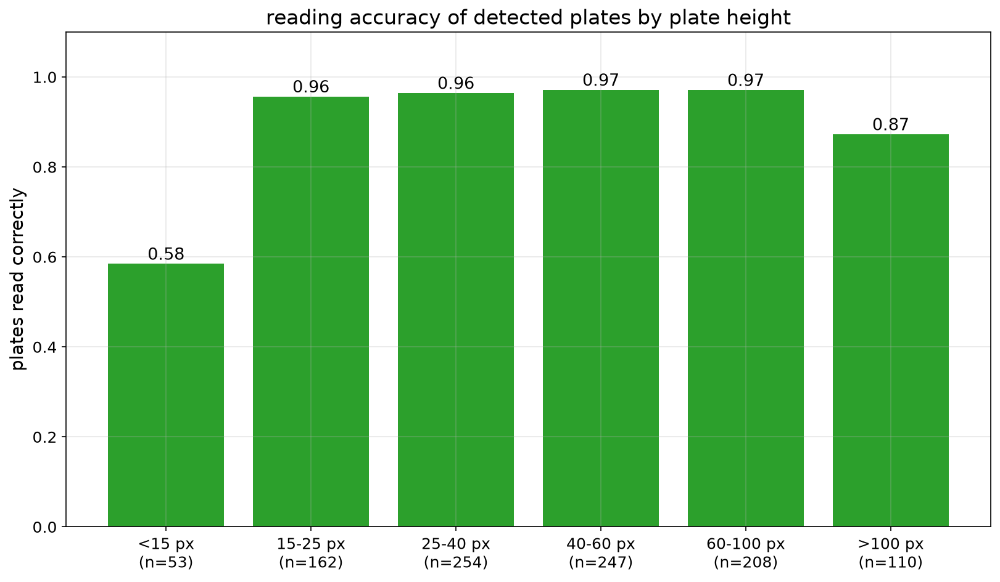

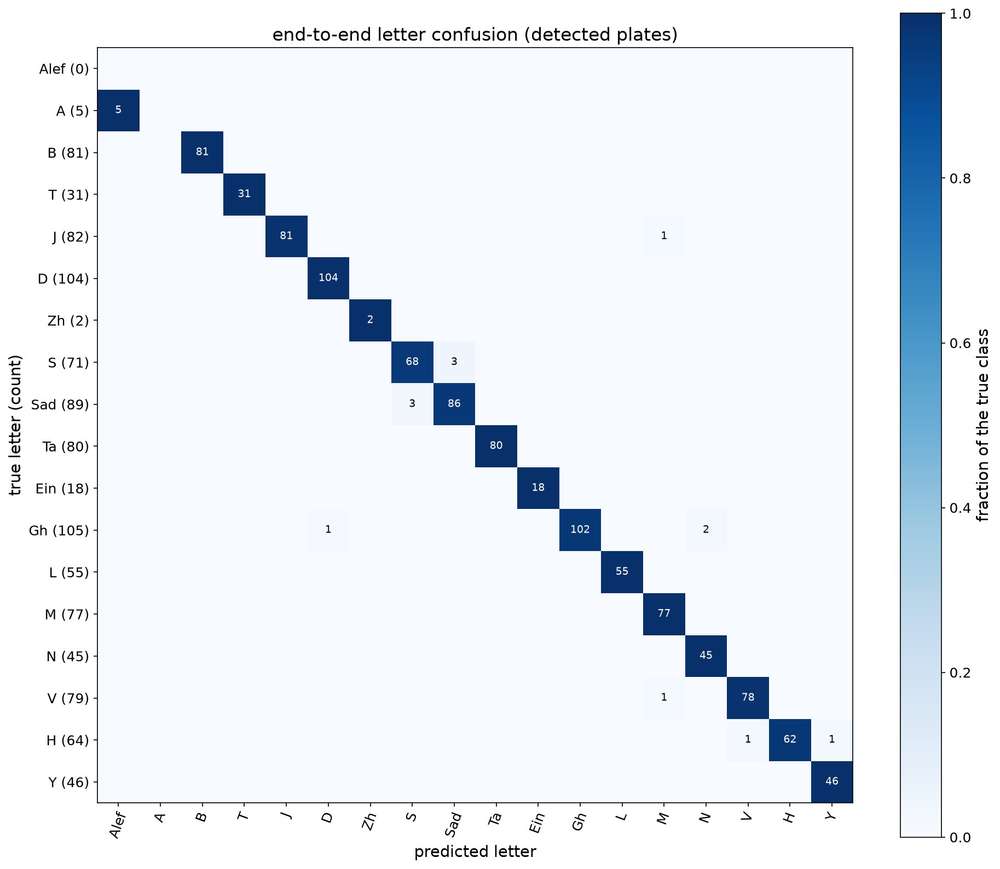

In [4]:
for name in ["e2e_summary", "e2e_threshold_sweep", "e2e_error_breakdown", "e2e_position_accuracy",
             "e2e_accuracy_by_plate_height", "e2e_letter_confusion"]:
    display(Image(filename=str(REPORT / "figures" / f"{name}.png"), width=900))

## 3. Examples

The examples below are drawn from the test split: correct reads, wrong reads, and plates the detector missed.

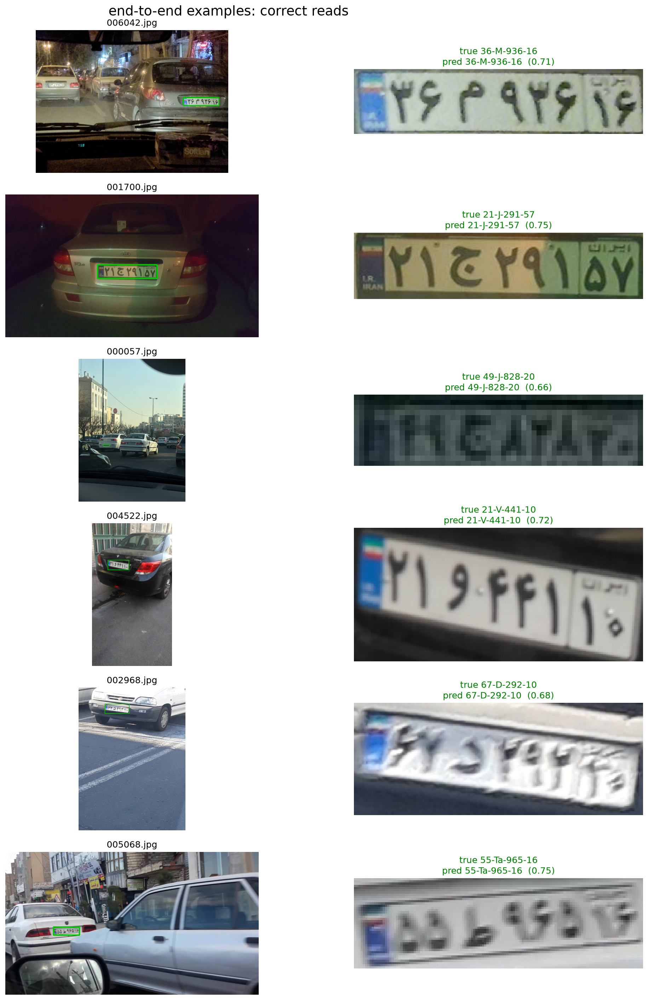

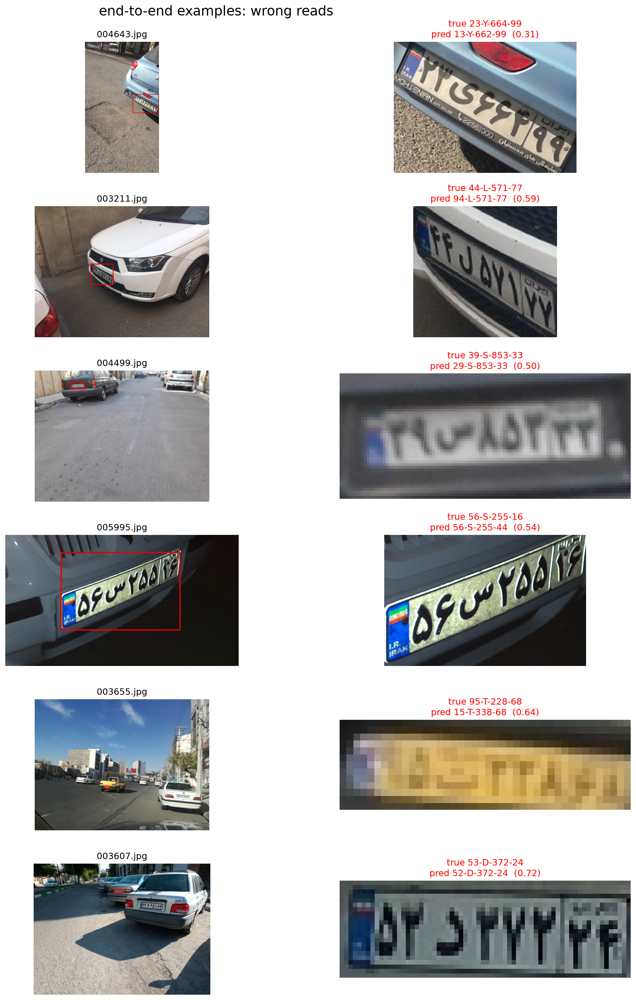

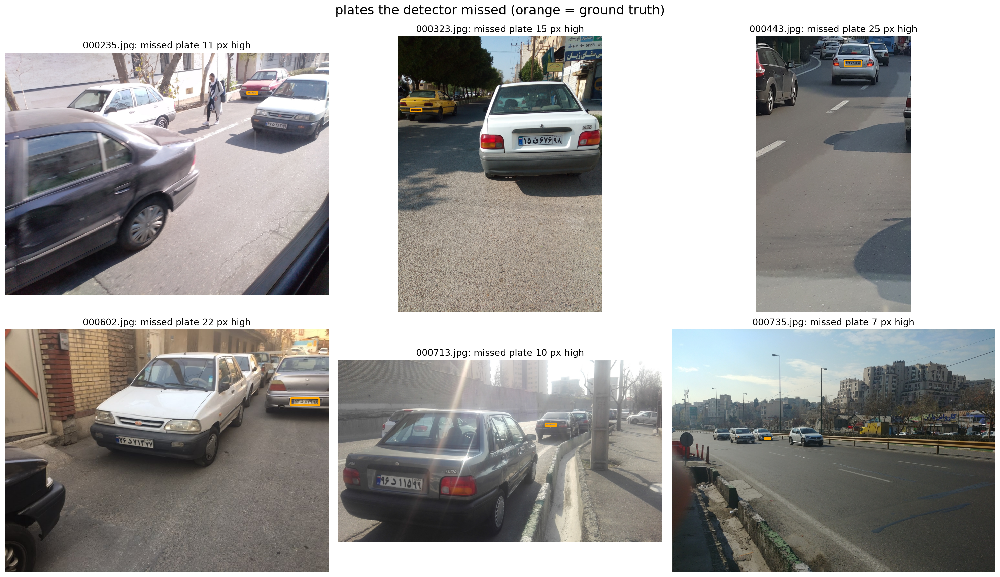

In [5]:
for name in ["e2e_examples_correct", "e2e_examples_wrong", "e2e_missed_plates"]:
    display(Image(filename=str(REPORT / "figures" / f"{name}.png"), width=1000))

## 4. Live demo on test photos

Each label shows the plate in the order printed on it (two digits, letter, three digits, region code) and the reading confidence.

000087.jpg | predicted: ['15ط38217'] | ground truth: ['15ط38217']


000088.jpg | predicted: ['57ه86521'] | ground truth: ['57ه86521']
000090.jpg | predicted: ['18س92111'] | ground truth: ['18س92111']
000092.jpg | predicted: ['95و86516'] | ground truth: ['95و86516']


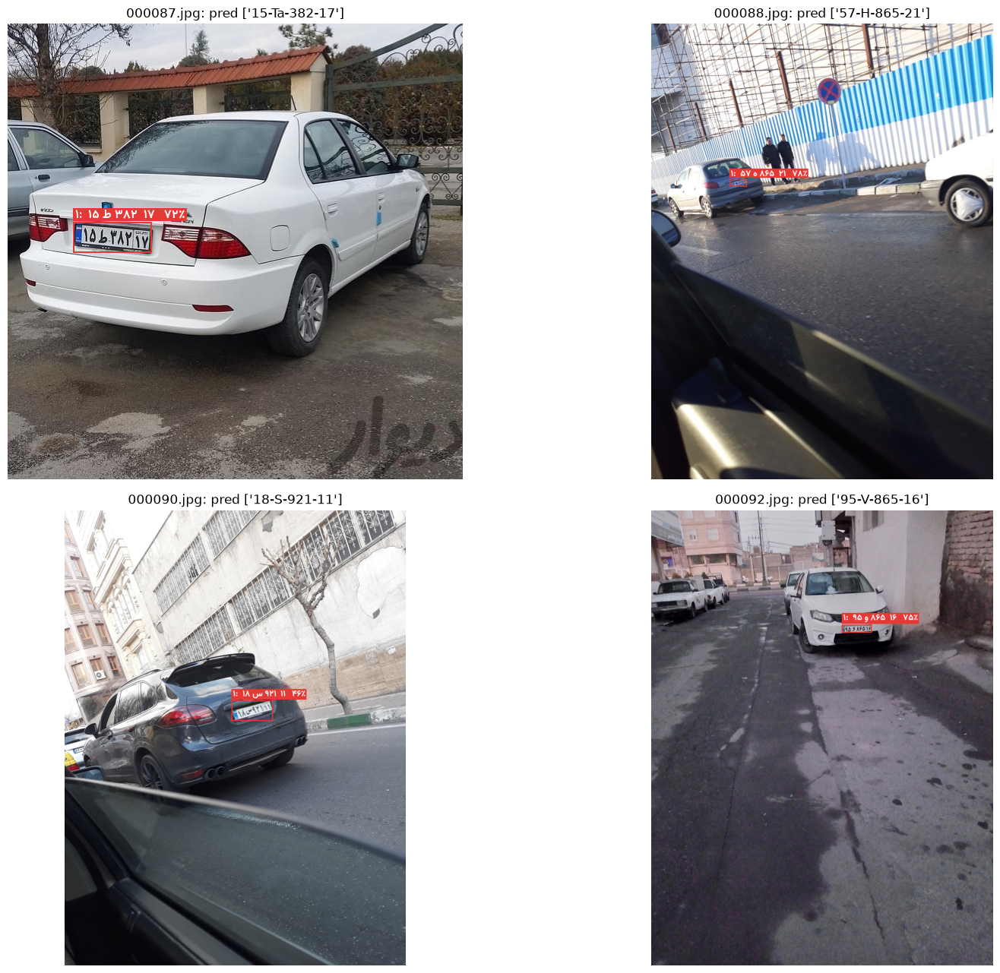

In [6]:
test_files = (ROOT / "models" / "splits" / "lpd_test_split.txt").read_text().split()
gt = {r.image_path: r.label for r in pd.read_csv(ROOT / "data" / "LPD" / "plate_labels.csv", dtype=str).itertuples()}
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
for ax, f in zip(axes.ravel(), test_files[20:24]):
    path = ROOT / "data" / "LPD" / "images" / f
    plates = reader.predict(path)
    ax.imshow(reader.draw(path, plates))
    ax.set_title(f"{f}: pred {[p.latin for p in plates]}", fontsize=12)
    ax.axis("off")
    print(f, "| predicted:", [p.text for p in plates], "| ground truth:", gt.get(f, "").split())
plt.tight_layout()
plt.show()

## 5. Conclusions

* **The detector is strong** (test mAP50 about 0.99). Most missed plates are tiny (under 15–25 px high) or partly outside the image, and some "false boxes" are real plates the annotation missed.
* **About 89% of all test plates are read completely correctly end to end.** About 94% of the plates the detector does find are read correctly, the same as the recognizer's accuracy on clean crops in Phase 2. The two stages therefore add up as expected, with no extra loss from cropping.
* **Remaining errors are mostly one wrong digit** on blurry, dark, tilted or very small plates. They are flagged by a low reading confidence, which the apps show as ⚠️.
* **Best operating point:** a detector threshold of about 0.65 maximizes end-to-end F1. That's close to the Phase 1 F1-optimal threshold of 0.618.